In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

c:\Users\User\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA = df[df['job_title_short']=='Data Analyst'].copy()

In [4]:
df_DA['job_skills'] = df_DA['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
df_DA_exploded = df_DA.explode('job_skills')

In [6]:
from adjustText import adjust_text

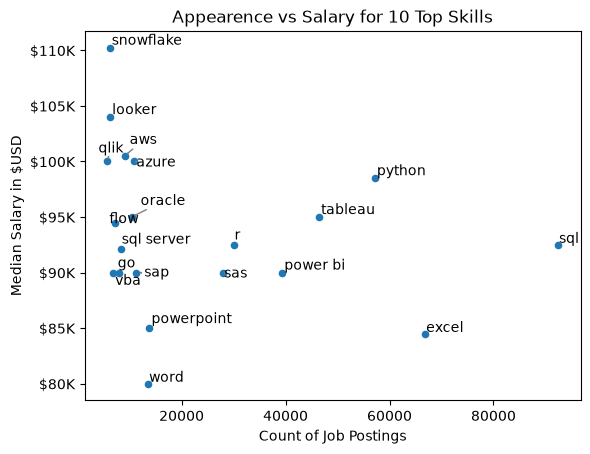

In [15]:
df_DA_grouped = df_DA_exploded.groupby('job_skills').agg(
    skills_count = ('job_skills','count'),
    median_salary = ('salary_year_avg', 'median')
)
df_DA_sorted = df_DA_grouped.sort_values(by='skills_count', ascending=False).head(20)
df_DA_sorted.plot(kind='scatter', x='skills_count', y='median_salary')

texts = []
for i, skill in enumerate(df_DA_sorted.index):
    texts.append(plt.text(df_DA_sorted['skills_count'].iloc[i], df_DA_sorted['median_salary'].iloc[i], skill))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary in $USD')
plt.title('Appearence vs Salary for 10 Top Skills')

plt.show()
